In [1]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
import os
#os.chdir("..")
os.getcwd()

'/home/akshey/Desktop/PhD/Code_repositories/bundlenet_results/c_elegans_results/c_elegans_embedding_evaluation'

## Behaviour evaluation plots

/tmp/ipykernel_366205/1636890730.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(algorithm_names, rotation=90)


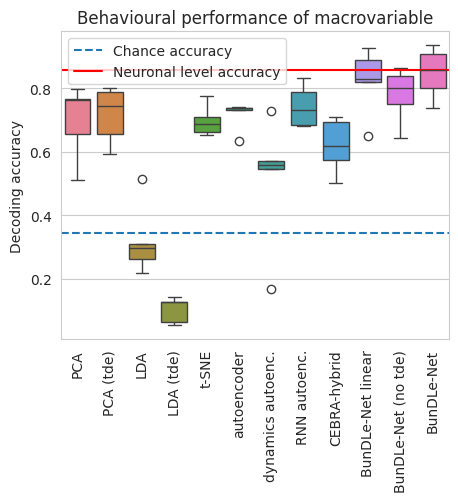

In [25]:
### POOLING WORMS
algorithms = [
    'PCA',
    'PCA_time_delay_embedding', 
    'LDA',
    'LDA_time_delay_embedding',
    'tsne',
    'autoencoder_time_delay_embedding',
    'dynamics_autoencoder_time_delay_embedding',
    'rnn_autoencoder',
    'cebra_h',
    'BunDLeNet_linear',
    'BunDLeNet_win_1',
    'BunDLeNet'
]
acc_array = []
for alg in algorithms:
    worm_i_acc = []
    worm_chance_acc = []
    worm_X_acc = []
    for worm_num in range(5):
        acc = np.loadtxt('data/generated/c_elegans_evaluation_metrics/acc_list_' + alg + '_worm_' +  str(worm_num))
        X_acc = np.loadtxt('data/generated/c_elegans_evaluation_metrics/acc_list_X_worm_'+str(worm_num)).mean()
        chance_acc = np.loadtxt('data/generated/c_elegans_evaluation_metrics/acc_list_chance_worm_'+str(worm_num)).mean()
        worm_i_acc.append(acc.mean())
        worm_chance_acc.append(chance_acc)
        worm_X_acc.append(X_acc)
        
    acc_array.append(worm_i_acc)
acc_array = np.array(acc_array)
worm_chance_acc = np.array(worm_chance_acc)
worm_X_acc = np.array(worm_X_acc)


plt.figure(figsize=(5,4))
ax = sns.boxplot(data=acc_array.T[:,:])
algorithm_names = [
    'PCA',
    'PCA (tde)', 
    'LDA',
    'LDA (tde)',
    't-SNE',
    'autoencoder',
    'dynamics autoenc.',
    'RNN autoenc.',
    'CEBRA-hybrid',
    'BunDLe-Net linear',
    'BunDLe-Net (no tde)',
    'BunDLe-Net'
]
ax.set_xticklabels(algorithm_names, rotation=90)
ax.set(ylabel = "Decoding accuracy", title ='Behavioural performance of macrovariable')
ax.axhline(worm_chance_acc.mean(), linestyle='--',label='Chance accuracy') ### Chance accuracy (see Evaluation .ipynb)
ax.axhline(worm_X_acc.mean(), linestyle='-',label='Neuronal level accuracy', color='red') ### Chance accuracy (see Evaluation .ipynb)

ax.legend()

In [26]:
# Define colors
neutral_color = "lightgray"
highlight_muted = sns.color_palette("Set1")[2]   # muted highlight (e.g., greenish)
highlight_bright = sns.color_palette("Set1")[0]  # brighter highlight (e.g., red-ish)
neutral = "#AEC6CF"           # soft muted blue
highlight_muted = "#66C2A5"   # soft teal (Set2)
highlight_bright = "#FC8D62"  # bright orange (Set1)

# Assume acc_array.T[:6] corresponds to 6 algorithms; last 3 are BundleNets
n = acc_array.shape[0]
colors = [neutral_color] * (n - 3) + [highlight_muted, highlight_muted, highlight_bright]


/tmp/ipykernel_366205/1482266894.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(algorithm_names, rotation=90, fontsize=11)


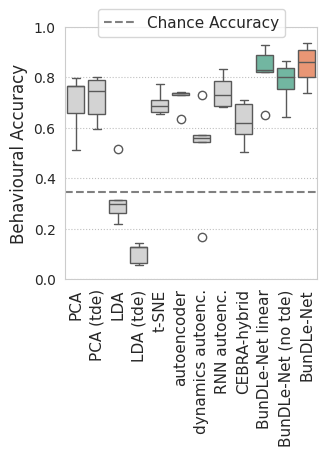

In [34]:
sns.set_style("whitegrid")
# color_palette = sns.color_palette("Set3")
plt.figure(figsize=(3.5, 4))
ax = sns.boxplot(data=acc_array.T, linewidth=1, palette=colors)
ax.set_xticklabels(algorithm_names, rotation=90, fontsize=11)
ax.set_ylabel("Behavioural Accuracy", fontsize=12)
ax.axhline(worm_chance_acc.mean(), linestyle='--', label='Chance Accuracy', color='gray')
#ax.axhline(worm_X_acc.mean(), linestyle='-', label='Neuronal Level Accuracy', color='black')
ax.grid(axis='y', linestyle=':', color='gray', alpha=0.5)
ax.set_ylim(0,1)
plt.subplots_adjust(bottom=0.25, left=0.18)
ax.legend(fontsize=11, loc='upper center', bbox_to_anchor=(0.5, 1.1), ncol=2)
plt.savefig('figures/behavioural_performance.svg', bbox_inches='tight', transparent=True)
plt.show()

In [20]:
# Evaluations for each worm individually
'''
for worm_num in range(5):
    acc_array = []
    algorithms = ['PCA', 'tsne', 'cebra_h', 'autoencoder', 'ArAe', 'BunDLeNet']
    for alg in algorithms:
        acc_array.append( np.loadtxt('data/generated/c_elegans_evaluation_metrics/acc_list_' + alg + '_worm_' +  str(worm_num)) )
    acc_array = np.array(acc_array)
    ### Neuronal level accuracy (X)
    X_acc = np.loadtxt('data/generated/c_elegans_evaluation_metrics/acc_list_X_worm_'+str(worm_num)).max()
    chance_acc = np.loadtxt('data/generated/c_elegans_evaluation_metrics/acc_list_chance_worm_'+str(worm_num)).mean()



    plt.figure(figsize=(5,4))
    ax = sns.boxplot(data=acc_array.T[:,:7])
    ax.set_xticklabels(['PCA', 'tsne', 'CEBRA-h', 'autoencoder', 'ArAe', 'BunDLe Net'], rotation=40)
    ax.set(ylabel = "Decoding accuracy", title ='Behavioural performance of macrovariable')
    ax.axhline(chance_acc, linestyle='--',label='Chance accuracy') ### Chance accuracy (see Evaluation .ipynb)
    ax.axhline(X_acc, linestyle='-',label='Neuronal level accuracy', color='red') ### Chance accuracy (see Evaluation .ipynb)
    ax.set_ylim([0,1])
    ax.legend()
    #plt.savefig('behavioural_performance.pdf', transparent=True)
'''

'\nfor worm_num in range(5):\n    acc_array = []\n    algorithms = [\'PCA\', \'tsne\', \'cebra_h\', \'autoencoder\', \'ArAe\', \'BunDLeNet\']\n    for alg in algorithms:\n        acc_array.append( np.loadtxt(\'data/generated/c_elegans_evaluation_metrics/acc_list_\' + alg + \'_worm_\' +  str(worm_num)) )\n    acc_array = np.array(acc_array)\n    ### Neuronal level accuracy (X)\n    X_acc = np.loadtxt(\'data/generated/c_elegans_evaluation_metrics/acc_list_X_worm_\'+str(worm_num)).max()\n    chance_acc = np.loadtxt(\'data/generated/c_elegans_evaluation_metrics/acc_list_chance_worm_\'+str(worm_num)).mean()\n\n\n\n    plt.figure(figsize=(5,4))\n    ax = sns.boxplot(data=acc_array.T[:,:7])\n    ax.set_xticklabels([\'PCA\', \'tsne\', \'CEBRA-h\', \'autoencoder\', \'ArAe\', \'BunDLe Net\'], rotation=40)\n    ax.set(ylabel = "Decoding accuracy", title =\'Behavioural performance of macrovariable\')\n    ax.axhline(chance_acc, linestyle=\'--\',label=\'Chance accuracy\') ### Chance accuracy (see E

## Dynamics evaluation plots

/tmp/ipykernel_366205/2168885717.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(algorithms, rotation=90, fontsize=10)
/tmp/ipykernel_366205/2168885717.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


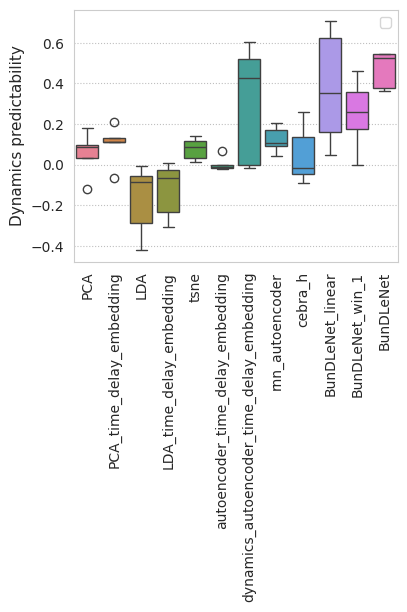

In [21]:
### POOLING WORMS
dp_array = []
for alg in algorithms:
    worm_i_dp = []
    for worm_num in range(5):
        mse = np.loadtxt('data/generated/c_elegans_evaluation_metrics/mse_list_' + alg + '_worm_' +  str(worm_num))
        dyn_pred = 1 -  mse[:,3]/mse[:,2]
        worm_i_dp.append(dyn_pred.mean())

    dp_array.append(worm_i_dp)
    
dp_array = np.array(dp_array)


plt.figure(figsize=(4.5, 4))
ax = sns.boxplot(data=dp_array.T, linewidth=1)
ax.set_xticklabels(algorithms, rotation=90, fontsize=10)
ax.yaxis.set_label_text("Dynamics predictability", fontsize=11)
#ax.axhline(0.0, linestyle='--',label='Baseline model', color='gray') ### Baseline goodness of fit (by definition)
plt.grid(axis='y', linestyle=':', color='gray', alpha=0.5)
# Adjust the bottom margin
plt.subplots_adjust(bottom=0.25, left=0.18)  # You can modify this value as needed
ax.legend()

/tmp/ipykernel_366205/1500496760.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(algorithm_names, rotation=90, fontsize=11)


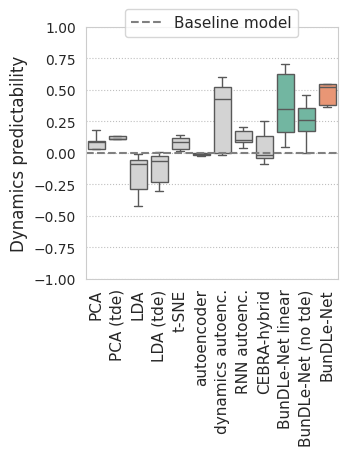

In [35]:
sns.set_style("whitegrid")
#color_palette = sns.color_palette("Set3")
plt.figure(figsize=(3.5, 4))
ax = sns.boxplot(data=dp_array.T[:6], linewidth=1, palette=colors, fliersize=0)
ax.set_xticklabels(algorithm_names, rotation=90, fontsize=11)
ax.yaxis.set_label_text("Dynamics predictability", fontsize=12)

ax.axhline(0.0, linestyle='--',label='Baseline model', color='gray') ### Baseline goodness of fit (by definition)
ax.grid(axis='y', linestyle=':', color='gray', alpha=0.5)
ax.set_ylim(-1,1)
plt.subplots_adjust(bottom=0.25, left=0.18)
ax.legend(fontsize=11, loc='upper center', bbox_to_anchor=(0.5, 1.1), ncol=2)
plt.savefig('figures/dynamical_performance.svg', bbox_inches='tight', transparent=True)
plt.show()

In [9]:
''' # Evaluations for each worm individually
for worm_num in range(5):
    mse_array = []
    algorithms = ['PCA', 'tsne', 'cebra_h', 'autoencoder', 'ArAe', 'BunDLeNet']
    for alg in algorithms:
        filename = 'data/generated/c_elegans_evaluation_metrics/mse_list_' + alg + '_worm_' +  str(worm_num)
        mse_array.append(np.loadtxt(filename))
    mse_array = np.array(mse_array)
    goodness_of_fit = 1 -  mse_array[:,:,3]/mse_array[:,:,2]


    plt.figure(figsize=(4.5, 4))
    ax = sns.violinplot(data=goodness_of_fit.T, linewidth=.5)
    ax.set_xticklabels(['PCA', 't-SNE', 'CEBRA-h', 'autoencoder', 'ArAe', 'BunDLe-Net'], rotation=40, fontsize=10)
    ax.yaxis.set_label_text("Dynamics predictability", fontsize=11)
    ax.axhline(0.0, linestyle='--',label='Baseline model', color='gray') ### Baseline goodness of fit (by definition)
    plt.grid(axis='y', linestyle=':', color='gray', alpha=0.5)
    # Adjust the bottom margin
    plt.subplots_adjust(bottom=0.25, left=0.18)  # You can modify this value as needed
    ax.legend()
'''

' # Evaluations for each worm individually\nfor worm_num in range(5):\n    mse_array = []\n    algorithms = [\'PCA\', \'tsne\', \'cebra_h\', \'autoencoder\', \'ArAe\', \'BunDLeNet\']\n    for alg in algorithms:\n        filename = \'data/generated/c_elegans_evaluation_metrics/mse_list_\' + alg + \'_worm_\' +  str(worm_num)\n        mse_array.append(np.loadtxt(filename))\n    mse_array = np.array(mse_array)\n    goodness_of_fit = 1 -  mse_array[:,:,3]/mse_array[:,:,2]\n\n\n    plt.figure(figsize=(4.5, 4))\n    ax = sns.violinplot(data=goodness_of_fit.T, linewidth=.5)\n    ax.set_xticklabels([\'PCA\', \'t-SNE\', \'CEBRA-h\', \'autoencoder\', \'ArAe\', \'BunDLe-Net\'], rotation=40, fontsize=10)\n    ax.yaxis.set_label_text("Dynamics predictability", fontsize=11)\n    ax.axhline(0.0, linestyle=\'--\',label=\'Baseline model\', color=\'gray\') ### Baseline goodness of fit (by definition)\n    plt.grid(axis=\'y\', linestyle=\':\', color=\'gray\', alpha=0.5)\n    # Adjust the bottom margin\n  